3. Housing Price Prediction

 Check the dataset for missing values and handle, if any.

 Display input and output features of the dataset.

 Encode non-numeric input attributes using label encoder.

 Normalize input and output attributes using standard scalar.

 Split dataset into training/validation/test sets in 70:15:15 ratio.

 Construct an MLP with configuration 12x128x64x32x16x1. Use Adam optimizer and appropriate activation functions and train the model.

 Predict house price for test data.

 Perform inverse transformation of predicted and actual house price.

 Compute and display RMSE, MAE and MAPE.

In [17]:
# Getting the CSV file from the drive
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

# Update this path to match where your file is in your Drive
file_path = '/content/drive/My Drive/Colab Notebooks/Yujan_NN/NN_Lab3/Housing.csv'

# Read the CSV
df = pd.read_csv(file_path)

# 1.  Check the dataset for missing values and handle, if any.

# Printing the dataset
print(df)

# Check for any missing values in each column
print("\n\nMissing values:\n", df.isnull().sum())




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
        price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no   

In [18]:
# 2.  Display input and output features of the dataset.
# Show all column names
print("Total columns:", list(df.columns))

# Separate features and target variable
target = 'price'
X = df.drop(target, axis=1)  # Input features
y = df[target]               # Output feature (house price)

# Print a few input column names
print("\nInput variables:\n", list(X)[:5])
print("\nTarget variable:\n", target)


Total columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Input variables:
 ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad']

Target variable:
 price


In [19]:
# 3. Encode non-numeric input attributes using LabelEncoder

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

# Columns that are non-numeric and need encoding
categorical_cols = ['mainroad', 'guestroom', 'basement',
                    'hotwaterheating', 'airconditioning',
                    'prefarea', 'furnishingstatus']

# Apply label encoding to each of them
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])  # Replace column with encoded values
    label_encoders[col] = le  # Save encoder in case you want to reverse later

print("After encoding:\n", df.head())


After encoding:
       price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus  
0                 0  
1                 0  
2                 1  
3                 0  
4                 0  


In [20]:
# 4.  Normalize input and output attributes using standard scalar.

# Separate input features again after encoding
Input_features = [col for col in df.columns if col != target]

# Initialize the scalers
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Normalize input and output
X_normalized = scaler_X.fit_transform(df[Input_features])
y = df[target].values.reshape(-1, 1)  # Make it 2D
y_normalized = scaler_y.fit_transform(y)

# Show first 5 scaled rows
print("Normalized inputs:\n", X_normalized[:5])
print("Normalized target:\n", y_normalized[:5])


Normalized inputs:
 [[ 1.04672629  1.40341936  1.42181174  1.37821692  0.40562287 -0.46531479
  -0.73453933 -0.2192645   1.4726183   1.51769249  1.80494113 -1.40628573]
 [ 1.75700953  1.40341936  5.40580863  2.53202371  0.40562287 -0.46531479
  -0.73453933 -0.2192645   1.4726183   2.67940935 -0.55403469 -1.40628573]
 [ 2.21823241  0.04727831  1.42181174  0.22441013  0.40562287 -0.46531479
   1.3613975  -0.2192645  -0.67906259  1.51769249  1.80494113 -0.09166185]
 [ 1.08362412  1.40341936  1.42181174  0.22441013  0.40562287 -0.46531479
   1.3613975  -0.2192645   1.4726183   2.67940935  1.80494113 -1.40628573]
 [ 1.04672629  1.40341936 -0.57018671  0.22441013  0.40562287  2.14908276
   1.3613975  -0.2192645   1.4726183   1.51769249 -0.55403469 -1.40628573]]
Normalized target:
 [[4.56636513]
 [4.00448405]
 [4.00448405]
 [3.98575468]
 [3.55497918]]


In [27]:
# 5. Split dataset into training/validation/test sets in 70:15:15 ratio

from sklearn.model_selection import train_test_split

# First split into 70% training, and remaining 30% is saved into a temporary set to be later split into validation and test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_normalized, y_normalized,       # input and output data (already normalized)
    test_size=0.3,                    # 30% of the data goes to temp (validation + test)
    random_state=42                   # seed value to make results repeatable
)

# Now split the temporary 30% data into two equal parts (15% each):
# 15% for validation (used to tune the model)
# 15% for testing (used to evaluate model performance at the end)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,                    # half of the 30% goes to testing
    random_state=42
)

print("\nDataset sizes:")
print(f"Training: {X_train.shape[0]}")     # number of samples in training set
print(f"Validation: {X_val.shape[0]}")     # number of samples in validation set
print(f"Testing: {X_test.shape[0]}")       # number of samples in test set



Dataset sizes:
Training: 381
Validation: 82
Testing: 82


In [22]:
#  Construct an MLP with configuration 12x128x64x32x16x1. Use Adam optimizer and appropriate activation functions and train the model.

import tensorflow as tf

# Create the model using TensorFlow Keras
model = tf.keras.models.Sequential([
    # Input layer with 128x64x32x16x1 neurons and ReLU activation function
    # Input shape matches the number of features (12 input features in this case)
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),  # 12 input features
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),

    # Output layer with 1 neuron (for the predicted price)
    # No activation function is used for the output layer because it's a regression problem
    tf.keras.layers.Dense(1)  # Output layer, no activation for regression
])

# Compile the model:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),  # Use Adam optimizer with learning rate of 0.001
    loss='mean_squared_error',  # Loss function: Mean Squared Error (for regression)
    metrics=['mae']  # Additional metric: Mean Absolute Error (for evaluation)
)

# Use EarlyStopping to avoid overfitting during training
# EarlyStopping will stop training if the validation loss does not improve for 20 epochs
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=20,         # Stop after 20 epochs with no improvement
    restore_best_weights=True  # Restore the weights of the best model (lowest validation loss)
)

# Train the model:
history = model.fit(
    X_train, y_train,  # Training data
    validation_data=(X_val, y_val),  # Validation data to monitor performance
    epochs=100,  # Train for up to 100 epochs (may stop earlier with EarlyStopping)
    batch_size=32,  # Number of samples per training batch
    callbacks=[early_stopping],  # Include EarlyStopping to prevent overfitting
    verbose=1  # Print progress during training
)


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.6643 - mae: 0.6395 - val_loss: 0.6699 - val_mae: 0.6330
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3359 - mae: 0.4605 - val_loss: 0.4619 - val_mae: 0.5020
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2529 - mae: 0.3669 - val_loss: 0.4478 - val_mae: 0.4862
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2145 - mae: 0.3224 - val_loss: 0.4451 - val_mae: 0.4992
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1693 - mae: 0.3029 - val_loss: 0.4403 - val_mae: 0.4900
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1750 - mae: 0.3078 - val_loss: 0.4318 - val_mae: 0.4902
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1456 - mae: 0.2896 - val_loss: 0.4306 - val_mae: 0.4879
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1747 - mae: 0.2961 - val_loss: 0.4479 - val_mae: 0.4996
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1498 -

In [23]:
#  7. Predict house price for test data

# Predict scaled prices
y_pred_scaled = model.predict(X_test)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


In [24]:
# 8. Perform inverse transformation of predicted and actual house price


# Convert the scaled predictions back to their original house prices
# The model predictions were on a scaled/normalized range, so we need to inverse the transformation
y_pred = scaler_y.inverse_transform(y_pred_scaled)  # Convert predicted prices back to the original scale

# Convert the actual test prices (scaled) back to their original house prices
y_test_actual = scaler_y.inverse_transform(y_test)  # Convert actual test prices back to the original scale

# Compare a few predictions with actual values
results = pd.DataFrame({
    'Actual Price': y_test_actual.ravel(),  # Flatten the actual house prices (1D array for display)
    'Predicted Price': y_pred.ravel(),  # Flatten the predicted house prices (1D array for display)
    'Difference': (y_pred.ravel() - y_test_actual.ravel()),  # Difference between predicted and actual prices
    'Percentage Difference': ((y_pred.ravel() - y_test_actual.ravel()) / y_test_actual.ravel()) * 100  # Percentage difference
})

# Display the first 10 results for comparison
print(results.head(10))  # Show a table with actual vs predicted prices, difference, and percentage difference


   Actual Price  Predicted Price  Difference  Percentage Difference
0     2408000.0       2607569.75   199569.75               8.287780
1     1750000.0       3211097.00  1461097.00              83.491257
2     5810000.0       5130619.00  -679381.00             -11.693305
3     1750000.0       3397023.50  1647023.50              94.115629
4     5950000.0       4152417.25 -1797582.75             -30.211475
5     2520000.0       3696337.50  1176337.50              46.680060
6     4235000.0       3912107.75  -322892.25              -7.624374
7     2450000.0       2885767.75   435767.75              17.786439
8     8890000.0       6456923.00 -2433077.00             -27.368695
9     3255000.0       2669530.50  -585469.50             -17.986774


In [25]:
#  9. Compute and display RMSE, MAE and MAPE
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mae = mean_absolute_error(y_test_actual, y_pred)
mape = np.mean(np.abs((y_test_actual - y_pred) / y_test_actual)) * 100

print("\nEvaluation Metrics:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")



Evaluation Metrics:
RMSE: 1175310.91
MAE: 872919.36
MAPE: 19.99%


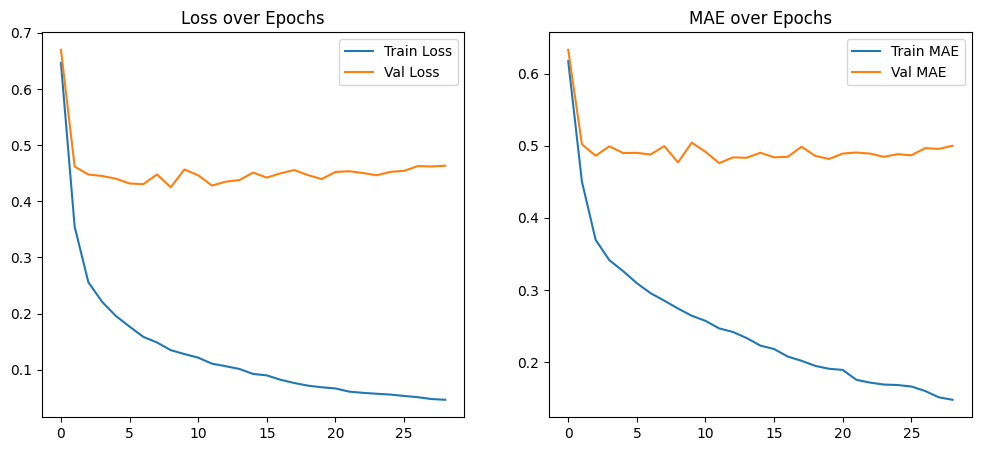

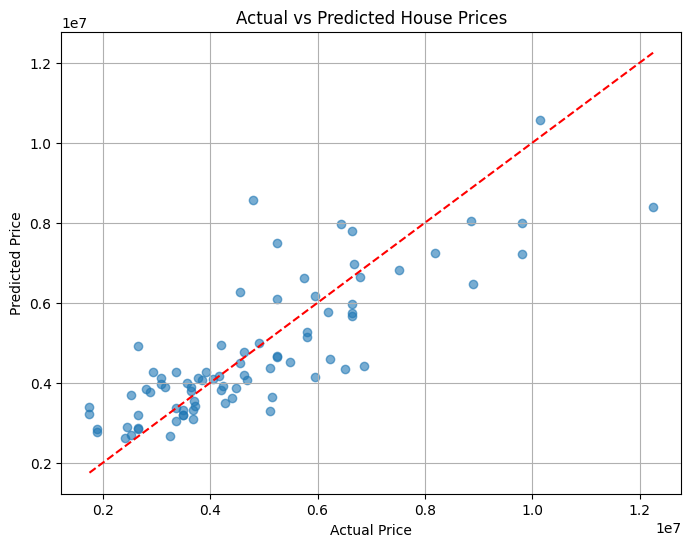

In [26]:
# Plot Predictions and loss curves
import matplotlib.pyplot as plt

# Plot the training history (Loss and MAE) to evaluate how well the model performed over time
plt.figure(figsize=(12, 5))

# Plot the loss curve (Train and Validation Loss)
plt.subplot(1, 2, 1)  # Create a subplot with 1 row and 2 columns (this is the first plot)
plt.plot(history.history['loss'], label='Train Loss')  # Plot training loss over epochs
plt.plot(history.history['val_loss'], label='Val Loss')  # Plot validation loss over epochs
plt.title('Loss over Epochs')  # Set the title of the plot
plt.legend()  # Show the legend to differentiate between train and validation loss

# Plot the Mean Absolute Error (MAE) curve (Train and Validation MAE)
plt.subplot(1, 2, 2)  # Create the second plot in the same row
plt.plot(history.history['mae'], label='Train MAE')  # Plot training MAE over epochs
plt.plot(history.history['val_mae'], label='Val MAE')  # Plot validation MAE over epochs
plt.title('MAE over Epochs')  # Set the title of the plot
plt.legend()  # Show the legend to differentiate between train and validation MAE

# Display both loss and MAE plots
plt.show()

# Plot a scatter plot to compare actual house prices with predicted ones
plt.figure(figsize=(8, 6))  # Set the figure size for the plot
plt.scatter(y_test_actual, y_pred, alpha=0.6)  # Plot actual vs predicted house prices as a scatter plot
plt.plot([y_test_actual.min(), y_test_actual.max()], [y_test_actual.min(), y_test_actual.max()], 'r--')  # Add a red dashed line representing perfect predictions
plt.xlabel('Actual Price')  # Label for the x-axis (actual house prices)
plt.ylabel('Predicted Price')  # Label for the y-axis (predicted house prices)
plt.title('Actual vs Predicted House Prices')  # Set the title of the plot
plt.grid(True)  # Add grid lines to the plot for better readability

# Display the scatter plot
plt.show()

